Carregando MNIST via fetch_openml...
Carregamento levou 2.49 segundos.
Usando 10000 amostras de treino e 1000 amostras de teste.

Iniciando simulação KNN para diferentes dimensões PCA...

--- Testando com N = 4 componentes ---
  1. Ajustando PCA (4 componentes)...
     Ajuste PCA levou 0.09s.
     Variância explicada: 0.2847
  2. Transformando dados...
     Transformação levou 0.02s.
  3. Aplicando StandardScaler...
  4. Treinando e avaliando KNN (k=5)...
     KNN (fit+predict) levou 0.03s.
     Acurácia: 0.6140
   -> Tempo total para N=4: 0.13s

--- Testando com N = 8 componentes ---
  1. Ajustando PCA (8 componentes)...
     Ajuste PCA levou 0.08s.
     Variância explicada: 0.4406
  2. Transformando dados...
     Transformação levou 0.01s.
  3. Aplicando StandardScaler...
  4. Treinando e avaliando KNN (k=5)...
     KNN (fit+predict) levou 0.06s.
     Acurácia: 0.8720
   -> Tempo total para N=8: 0.16s

--- Testando com N = 16 componentes ---
  1. Ajustando PCA (16 componentes)...
   

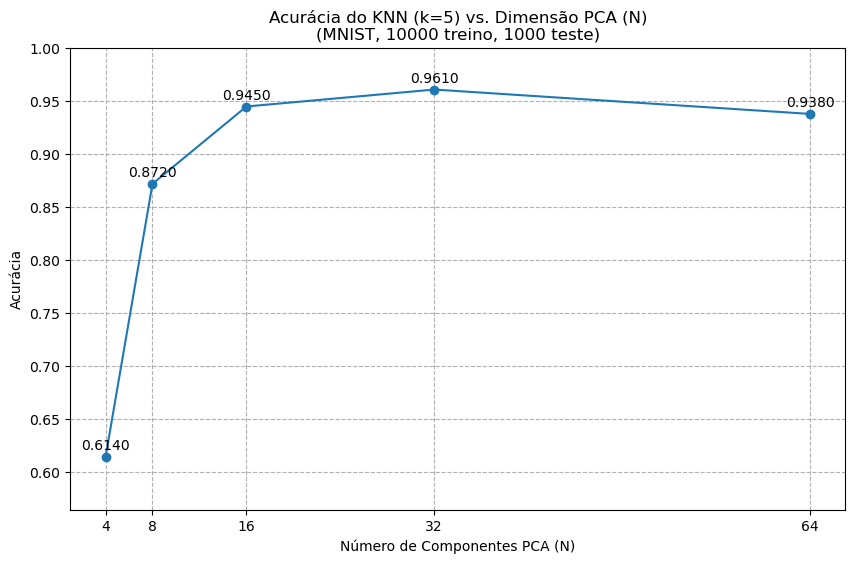


--- Análise de Tempos (média por iteração) ---
Tempo médio ajuste PCA: 0.11s
Tempo médio transformação PCA: 0.01s
Tempo médio KNN (fit+predict): 0.03s


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split # Para dividir os dados carregados

# --- Parâmetros da Simulação ---
N_TRAIN_SAMPLES = 10000
N_TEST_SAMPLES = 1000
KNN_NEIGHBORS = 5
# Dimensões PCA para testar (potências de 2)
PCA_DIMENSIONS = [4, 8, 16, 32, 64] # Corresponde a n = [2, 3, 4, 5, 6]

# --- Carregar e Preparar Dados MNIST ---
print("Carregando MNIST via fetch_openml...")
start_time = time.time()
try:
    mnist_data = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist_data["data"], mnist_data["target"]
    y = y.astype(np.uint8)
    # Normalizar pixels para float [0, 1] (comum para PCA)
    X = X / 255.0
    print(f"Carregamento levou {time.time() - start_time:.2f} segundos.")

    # Dividir em treino/teste e pegar subconjuntos
    # Usar train_test_split para garantir aleatoriedade na seleção do subconjunto
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=N_TRAIN_SAMPLES, test_size=N_TEST_SAMPLES,
        random_state=42, stratify=y # Mantém proporção das classes
    )
    print(f"Usando {X_train.shape[0]} amostras de treino e {X_test.shape[0]} amostras de teste.")

except Exception as e:
    print(f"ERRO CRÍTICO: Não foi possível baixar ou processar o dataset MNIST.")
    print(f"Erro: {e}")
    exit()

# --- Loop de Simulação ---
accuracies = []
fit_times = []
transform_times = []
knn_times = []

print("\nIniciando simulação KNN para diferentes dimensões PCA...")

for n_components in PCA_DIMENSIONS:
    print(f"\n--- Testando com N = {n_components} componentes ---")
    start_iter_time = time.time()

    # 1. PCA
    print(f"  1. Ajustando PCA ({n_components} componentes)...")
    pca = PCA(n_components=n_components, random_state=42)
    t0 = time.time()
    # PCA espera dados achatados (N_samples, N_features=784)
    # X_train e X_test já estão achatados pelo fetch_openml se as_frame=False
    pca.fit(X_train)
    t1 = time.time()
    fit_times.append(t1 - t0)
    print(f"     Ajuste PCA levou {t1 - t0:.2f}s.")
    print(f"     Variância explicada: {np.sum(pca.explained_variance_ratio_):.4f}")

    print("  2. Transformando dados...")
    t0 = time.time()
    train_pca = pca.transform(X_train)
    test_pca = pca.transform(X_test)
    t1 = time.time()
    transform_times.append(t1 - t0)
    print(f"     Transformação levou {t1 - t0:.2f}s.")

    # 3. Scaling
    print("  3. Aplicando StandardScaler...")
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_pca)
    test_scaled = scaler.transform(test_pca)

    # 4. KNN
    print(f"  4. Treinando e avaliando KNN (k={KNN_NEIGHBORS})...")
    knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, n_jobs=-1)
    t0 = time.time()
    knn.fit(train_scaled, y_train)
    predictions = knn.predict(test_scaled)
    t1 = time.time()
    knn_times.append(t1 - t0)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)
    print(f"     KNN (fit+predict) levou {t1-t0:.2f}s.")
    print(f"     Acurácia: {accuracy:.4f}")

    iter_duration = time.time() - start_iter_time
    print(f"   -> Tempo total para N={n_components}: {iter_duration:.2f}s")


# --- Plotar Resultados ---
print("\nSimulação concluída. Gerando gráfico...")

plt.figure(figsize=(10, 6))
plt.plot(PCA_DIMENSIONS, accuracies, marker='o', linestyle='-')
plt.title(f'Acurácia do KNN (k={KNN_NEIGHBORS}) vs. Dimensão PCA (N)\n(MNIST, {N_TRAIN_SAMPLES} treino, {N_TEST_SAMPLES} teste)')
plt.xlabel('Número de Componentes PCA (N)')
plt.ylabel('Acurácia')
plt.xticks(PCA_DIMENSIONS) # Garante ticks nos pontos testados
plt.grid(True, which='both', linestyle='--')
plt.ylim(bottom=min(accuracies)-0.05, top=1.0) # Ajusta limite inferior do y

# Adicionar valores de acurácia no gráfico
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt:.4f}", (PCA_DIMENSIONS[i], accuracies[i]), textcoords="offset points", xytext=(0,5), ha='center')

plt.show()

print("\n--- Análise de Tempos (média por iteração) ---")
print(f"Tempo médio ajuste PCA: {np.mean(fit_times):.2f}s")
print(f"Tempo médio transformação PCA: {np.mean(transform_times):.2f}s")
print(f"Tempo médio KNN (fit+predict): {np.mean(knn_times):.2f}s")

Carregando MNIST via fetch_openml...
Carregamento levou 2.00 segundos.
Dataset dividido em 60000 treino e 10000 teste.

Preparando conjunto de teste fixo e estratificado (1000 amostras)...
Distribuição de classes no teste: [(0, 100), (1, 100), (2, 100), (3, 100), (4, 100), (5, 100), (6, 100), (7, 100), (8, 100), (9, 100)]

Iniciando simulação KNN (N=16) para diferentes tamanhos de treino M...

--- Testando com M = 128 (m = 7) ---
  1. Selecionando 128 amostras de treino estratificadas...
  2. Ajustando PCA (N=16) em 128 amostras...
     Variância explicada: 0.6664
  3. Transformando treino e teste...
     Acurácia: 0.6740
   -> Tempo total para M=128: 0.01s

--- Testando com M = 256 (m = 8) ---
  1. Selecionando 256 amostras de treino estratificadas...
  2. Ajustando PCA (N=16) em 256 amostras...
     Variância explicada: 0.6276
  3. Transformando treino e teste...
     Acurácia: 0.7730
   -> Tempo total para M=256: 0.02s

--- Testando com M = 512 (m = 9) ---
  1. Selecionando 512 amos

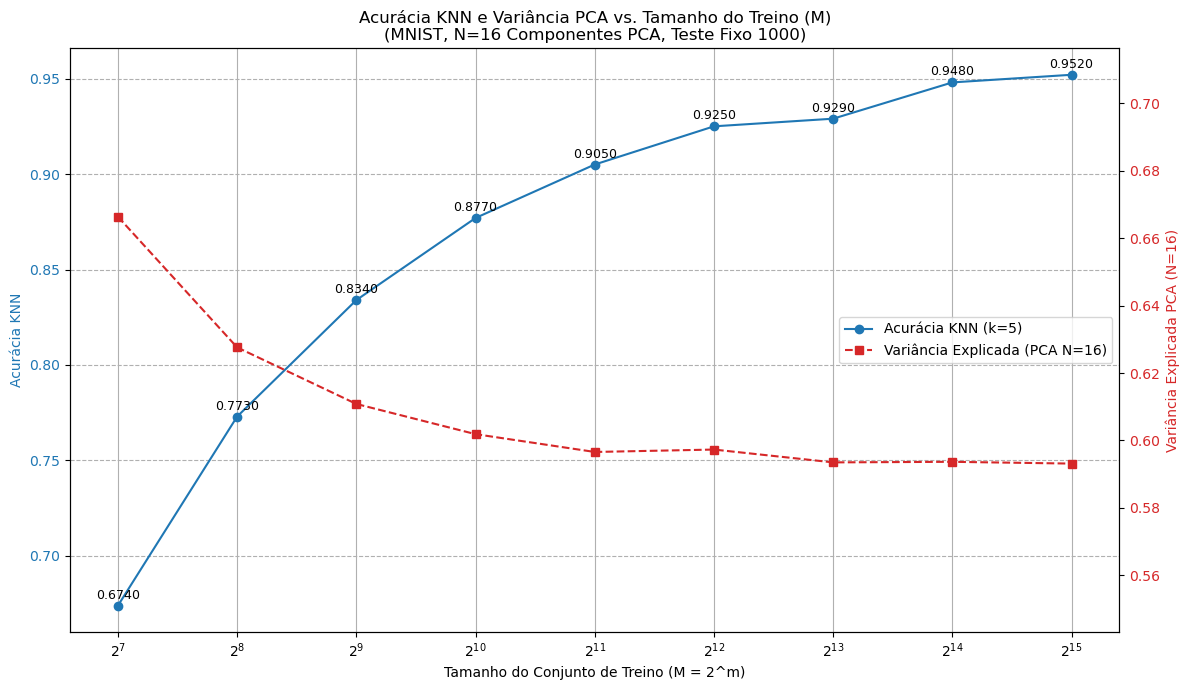


--- Análise para Limite de Qubits (Q_total = m + 2n + 5 <= 24) ---
Com n=4 (N=16), a restrição m + 2*(4) <= 19 implica m <= 11.
Portanto, o maior M viável seria M = 2^11 = 2048.
A acurácia obtida para M=2048 (m=11) foi: 0.9050

Analise o gráfico para ver como a acurácia se comporta até M=2048.
Se a acurácia for satisfatória em M=2048, m=11 e n=4 seria a escolha.


In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter

# --- Parâmetros da Simulação ---
N_COMPONENTS = 16 # N=16 fixo (n=4)
KNN_NEIGHBORS = 5
# Valores de m para testar M = 2^m
m_values = list(range(7, 16)) # m = 7 a 15
M_values = [2**m for m in m_values] # M = 128 a 32768
N_TEST_SAMPLES = 1000 # Tamanho do conjunto de teste fixo

# --- Carregar e Preparar Dados MNIST Completo ---
print("Carregando MNIST via fetch_openml...")
start_time = time.time()
try:
    # Carregar como DataFrame para facilitar amostragem estratificada inicial
    mnist_data = fetch_openml('mnist_784', version=1, as_frame=True, parser='auto')
    X_all_df = mnist_data.frame.drop('class', axis=1)
    y_all_sr = mnist_data.frame['class'].astype(np.uint8)

    # Normalizar pixels para float [0, 1]
    X_all_df = X_all_df / 255.0
    print(f"Carregamento levou {time.time() - start_time:.2f} segundos.")

    # Dividir os 70k iniciais em treino (60k) e teste (10k) padrão
    X_train_full_df, X_test_full_df, y_train_full_sr, y_test_full_sr = train_test_split(
        X_all_df, y_all_sr, test_size=10000, train_size=60000,
        random_state=42, stratify=y_all_sr
    )
    print(f"Dataset dividido em {len(X_train_full_df)} treino e {len(X_test_full_df)} teste.")

except Exception as e:
    print(f"ERRO CRÍTICO: Não foi possível baixar ou processar o dataset MNIST.")
    print(f"Erro: {e}")
    exit()

# --- Função para Amostragem Estratificada ---
def select_stratified_subset(X_df, y_sr, M):
    """Seleciona um subconjunto estratificado de tamanho M."""
    n_classes = len(y_sr.unique())
    samples_per_class = M // n_classes
    remainder = M % n_classes

    subset_indices = []
    for class_label in sorted(y_sr.unique()):
        class_indices = y_sr[y_sr == class_label].index
        n_samples_class = samples_per_class + (1 if remainder > 0 else 0)
        # Garante que não tentamos amostrar mais do que disponível
        n_samples_class = min(n_samples_class, len(class_indices))
        # Amostra aleatória sem reposição
        sampled_indices = np.random.choice(class_indices, size=n_samples_class, replace=False)
        subset_indices.extend(sampled_indices)
        if remainder > 0:
            remainder -= 1

    # Embaralhar os índices selecionados
    np.random.shuffle(subset_indices)
    # Retorna como arrays NumPy
    return X_df.loc[subset_indices].values, y_sr.loc[subset_indices].values

# --- Preparar Conjunto de Teste Fixo e Estratificado ---
print(f"\nPreparando conjunto de teste fixo e estratificado ({N_TEST_SAMPLES} amostras)...")
X_test_subset, y_test_subset = select_stratified_subset(X_test_full_df, y_test_full_sr, N_TEST_SAMPLES)
print(f"Distribuição de classes no teste: {sorted(Counter(y_test_subset).items())}")

# --- Loop de Simulação ---
accuracies_m = []
pca_variance = []

print(f"\nIniciando simulação KNN (N={N_COMPONENTS}) para diferentes tamanhos de treino M...")

for M in M_values:
    m = int(np.log2(M))
    print(f"\n--- Testando com M = {M} (m = {m}) ---")
    start_iter_time = time.time()

    # 1. Amostragem Estratificada do Treino
    print(f"  1. Selecionando {M} amostras de treino estratificadas...")
    X_train_M, y_train_M = select_stratified_subset(X_train_full_df, y_train_full_sr, M)
    # print(f"     Distribuição de classes no treino M={M}: {sorted(Counter(y_train_M).items())}")

    # 2. PCA (N=16) - Ajustado neste subconjunto M
    print(f"  2. Ajustando PCA (N={N_COMPONENTS}) em {M} amostras...")
    pca = PCA(n_components=N_COMPONENTS, random_state=42)
    pca.fit(X_train_M) # X_train_M já é numpy array
    variance_explained = np.sum(pca.explained_variance_ratio_)
    pca_variance.append(variance_explained)
    print(f"     Variância explicada: {variance_explained:.4f}")

    print("  3. Transformando treino e teste...")
    train_pca = pca.transform(X_train_M)
    # Transforma o CONJUNTO DE TESTE FIXO (X_test_subset) com o PCA atual
    test_pca = pca.transform(X_test_subset)

    # 4. Scaling
    # print("  4. Aplicando StandardScaler...")
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_pca)
    test_scaled = scaler.transform(test_pca)

    # 5. KNN
    # print(f"  5. Treinando e avaliando KNN (k={KNN_NEIGHBORS})...")
    knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, n_jobs=-1)
    knn.fit(train_scaled, y_train_M)
    predictions = knn.predict(test_scaled)
    accuracy = accuracy_score(y_test_subset, predictions)
    accuracies_m.append(accuracy)
    print(f"     Acurácia: {accuracy:.4f}")

    iter_duration = time.time() - start_iter_time
    print(f"   -> Tempo total para M={M}: {iter_duration:.2f}s")

# --- Plotar Resultados ---
print("\nSimulação concluída. Gerando gráfico...")

fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico da Acurácia
color = 'tab:blue'
ax1.set_xlabel('Tamanho do Conjunto de Treino (M = 2^m)')
ax1.set_ylabel('Acurácia KNN', color=color)
ax1.plot(M_values, accuracies_m, marker='o', linestyle='-', color=color, label='Acurácia KNN (k=5)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log', base=2) # Escala log base 2 para M
ax1.grid(True, which='major', linestyle='-', axis='x')
ax1.grid(True, which='minor', linestyle=':', axis='x')
ax1.grid(True, which='major', linestyle='--', axis='y')

# Adicionar valores de acurácia no gráfico
for i, txt in enumerate(accuracies_m):
    ax1.annotate(f"{txt:.4f}", (M_values[i], accuracies_m[i]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=9)

# Gráfico da Variância Explicada pelo PCA (no mesmo eixo x)
ax2 = ax1.twinx() # Compartilha o mesmo eixo x
color = 'tab:red'
ax2.set_ylabel('Variância Explicada PCA (N=16)', color=color)
ax2.plot(M_values, pca_variance, marker='s', linestyle='--', color=color, label=f'Variância Explicada (PCA N={N_COMPONENTS})')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(bottom=min(pca_variance)-0.05, top=max(pca_variance)+0.05)

plt.title(f'Acurácia KNN e Variância PCA vs. Tamanho do Treino (M)\n(MNIST, N={N_COMPONENTS} Componentes PCA, Teste Fixo {N_TEST_SAMPLES})')
fig.tight_layout() # Ajusta layout para não sobrepor labels
# Adicionar legendas combinadas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

plt.show()

# --- Análise para Qubits ---
print("\n--- Análise para Limite de Qubits (Q_total = m + 2n + 5 <= 24) ---")
n_fixed = 4 # N=16
max_m_allowed = 19 - 2 * n_fixed
print(f"Com n={n_fixed} (N=16), a restrição m + 2*({n_fixed}) <= 19 implica m <= {max_m_allowed}.")
print(f"Portanto, o maior M viável seria M = 2^{max_m_allowed} = {2**max_m_allowed}.")

# Encontrar a acurácia correspondente a m=11 (se existir no teste)
if max_m_allowed in m_values:
    idx_m11 = m_values.index(max_m_allowed)
    acc_m11 = accuracies_m[idx_m11]
    m_val_m11 = M_values[idx_m11]
    print(f"A acurácia obtida para M={m_val_m11} (m={max_m_allowed}) foi: {acc_m11:.4f}")
else:
     print(f"O valor m={max_m_allowed} não foi explicitamente testado nos M_values.")

print("\nAnalise o gráfico para ver como a acurácia se comporta até M=2048.")
print("Se a acurácia for satisfatória em M=2048, m=11 e n=4 seria a escolha.")